# データ取得

In [3]:

import os
import json

# ================================　デバイスリスト　　================================
device_list_path = "C:/Users/Tenma/Desktop/Keio/InteractiveSmartHome/InteractiveSmartHome/InteractiveSmartHome/Assets/EXPERIMENT/device_list.json"

with open(device_list_path, "r", encoding="utf-8") as f:
    all_device_lists = json.load(f)
    

# ================================　タスクセット　　================================

# ディレクトリパス
task_sets_path = "C:/Users/Tenma/Desktop/Keio/InteractiveSmartHome/InteractiveSmartHome/InteractiveSmartHome/Assets/EXPERIMENT/ArrangeData"

# 対象ファイル
file_names = ["PreTaskArrangementA.json", "PreTaskArrangementB.json", 
              "PreTaskArrangementC.json", "PreTaskArrangementD.json"]

# すべてのタスクを格納するリスト
all_task_sets = []

# 各ファイルを読み込んで統合
for file_name in file_names:
    file_path = os.path.join(task_sets_path, file_name)
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
        all_task_sets.extend(data)  # 各ファイルがリスト形式であることを前提

# 確認（最初の1件だけ表示）
print(all_task_sets[0])

task_id_to_info = {}

for task in all_task_sets:
    task_id_to_info[task["device_arrange_id"]] = {
        "name": task["device_arrange_name"],
        "devices": task["devices"]
    }





# ================================　処理結果　　================================

import os
import json
from collections import defaultdict

# フォルダパス
result_dir = "C:/Users/Tenma/Desktop/Keio/InteractiveSmartHome/InteractiveSmartHome/LLMServer/ExperimentData/RESULTS/SystemEvaluation"

# 除外する task_id のリスト（必要に応じて追加）
exclude_task_ids = {
    "b0e9f035-c92f-4dc6-bd0a-a10b2941f902"  # ← 外れ値
    # 他にも追加可能: "another-task-id", ...
}

# 結果を格納するネスト辞書
evaluation_results = defaultdict(dict)

# ファイル読み込みループ
for filename in os.listdir(result_dir):
    if filename.endswith(".json"):
        filepath = os.path.join(result_dir, filename)
        # ファイル名から model名 と 評価方式を抽出
        parts = filename.replace("SystemEvaluation_", "").replace(".json", "").split("_")
        model = parts[0]
        eval_type = parts[1] if len(parts) > 1 else "unknown"

        # JSONロード＋task_id除外
        with open(filepath, "r", encoding="utf-8") as f:
            data = json.load(f)

            # データがリスト形式なら除外フィルターをかける
            if isinstance(data, list):
                filtered_data = [entry for entry in data if entry.get("task_id") not in exclude_task_ids]
                evaluation_results[model][eval_type] = filtered_data
            else:
                evaluation_results[model][eval_type] = data  # 念のため辞書型も対応

# 利用例
print(evaluation_results["gpt-4o"]["pointing"][0])  # 最初のタスクの出力を確認



{'device_arrange_id': '2369c5c0-c4bb-4308-a9cd-05a64a69f91a', 'device_arrange_name': '手前三つ青奥三つ赤', 'device_arrange_type': [], 'devices': [{'deviceName': 'Ceiling Light 6', 'colorName': 'Blue', 'deviceId': '58126407-cde0-4d62-a13d-1a24bf8ea5f3'}, {'deviceName': 'Ceiling Light 2', 'colorName': 'Red', 'deviceId': '781e6091-cec9-4c26-9f3e-4d48d6d7570a'}, {'deviceName': 'Ceiling Light 4', 'colorName': 'Red', 'deviceId': '6ac4ec9f-0326-4619-b79a-ecbbe5459d23'}, {'deviceName': 'Ceiling Light 3', 'colorName': 'Red', 'deviceId': '6f1c35e2-1ca1-4f43-93cf-755d9479025b'}, {'deviceName': 'Ceiling Light 8', 'colorName': 'Blue', 'deviceId': '74a6f0f8-be5d-479e-9e08-91d6bd599916'}, {'deviceName': 'Ceiling Light 7', 'colorName': 'Blue', 'deviceId': 'e9a21485-0eb4-40ad-a985-cef8bc98d190'}]}
{'user_prompt': 'この二つをオレンジにして ', 'pointed_devices': [{'id': '3da605b5-b12f-4fe8-9108-f4a6648efb3b', 'name': 'Ceiling Light 11', 'position': {'x': 0.813812137, 'y': 2.25890779, 'z': -0.174801424}, 'distance_from_user':

In [22]:
a = evaluation_results["gpt-4o"]["system"][0]
a["agent_output"]

{'devices': [{'id': '9cbd6e9a-4f7b-41e8-b1dc-464d631dfd7f',
   'state': True,
   'intensity': 100,
   'color': {'r': 255, 'g': 165, 'b': 0}},
  {'id': '6e82a90c-d3bb-4e45-b221-ebe21c524b04',
   'state': True,
   'intensity': 100,
   'color': {'r': 255, 'g': 165, 'b': 0}}],
 'response': '俺の後ろの天井の右2つのライトをオレンジにしました。',
 'reasoning': 'ユーザーの指示に基づき、『後ろ』はz軸で負の方向を示し、『天井の右』はx軸におけるプラス方向を示します。デバイスの位置から、後ろの天井に2つ並んでいるデバイスを特定し、オレンジ色に設定しました。'}

In [23]:


COLOR_NAME_TO_RGB = {
    'Red':    (255, 0, 0),
    'Green':  (0, 128, 0),  # 一般的な緑
    'Blue':   (0, 0, 255),
    'Yellow': (255, 255, 0),
    'Cyan':   (0, 255, 255),
    'Purple': (128, 0, 128),
    'Orange': (255, 165, 0), # 提示された例の値
    'White':  (255, 255, 255),
    'Black':  (0, 0, 0)      # 参考として追加
}
def color_checker(agent_color, expected_color_name, threshold=80):
    if expected_color_name not in COLOR_NAME_TO_RGB:
        print(f"警告: '{expected_color_name}' は定義されていません。")
        return False

    target_r, target_g, target_b = COLOR_NAME_TO_RGB[expected_color_name]

    # エージェントの出力からRGB値を取得
    actual_r = agent_color.get('r', 0)
    actual_g = agent_color.get('g', 0)
    actual_b = agent_color.get('b', 0)

    # ユークリッド距離を計算
    distance = math.sqrt(
        (target_r - actual_r) ** 2 +
        (target_g - actual_g) ** 2 +
        (target_b - actual_b) ** 2
    )

    # 距離が閾値以下であればTrueを返す
    return distance <= threshold
    


### 可視化してみる

# 時間評価結果

In [24]:
import pandas as pd
def summarize_metrics(task_info: dict, evaluation_results: dict) -> pd.DataFrame:
    rows = []

    for model, eval_dict in evaluation_results.items():
        for eval_type, results in eval_dict.items():
            for record in results:
                task_id = record.get("task_id")

                # ✨ system_total_time_sec は record の最上位に存在
                system_time = record.get("system_total_time_sec")
                cost_usd = record.get("filterAgent", {}).get("metrics", {}).get("cost_usd") \
                    if eval_type == "system" else \
                    record.get("spatialAgent", {}).get("metrics", {}).get("cost_usd") \
                    if eval_type == "spatial" else \
                    record.get("metrics", {}).get("cost_usd")

                rows.append({
                    "model": model,
                    "eval_type": eval_type,
                    "system_time_sec": system_time,
                    "cost_usd": cost_usd,
                })

    df = pd.DataFrame(rows)

    df_summary = df.groupby(["model", "eval_type"]).agg({
        "system_time_sec": ["min", "max", "mean"],
        "cost_usd": ["min", "max", "mean"]
    }).reset_index()

    df_summary.columns = [
        "model", "eval_type",
        "system_time_min", "system_time_max", "system_time_mean",
        "cost_min", "cost_max", "cost_mean"
    ]

    

    return df_summary
import pandas as pd

# 元データ: df_result に各レコードの `system_time_elapsed` が含まれているとする
def remove_outliers_and_aggregate(df):
    grouped_results = []

    # モデル・評価方式ごとに処理
    for (model, eval_type), group in df.groupby(["model", "eval_type"]):
        times = group["system_time_elapsed"]

        # IQRによる外れ値検出
        Q1 = times.quantile(0.25)
        Q3 = times.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # 外れ値除去
        filtered = group[(times >= lower_bound) & (times <= upper_bound)]

        # 集計
        result = {
            "model": model,
            "eval_type": eval_type,
            "system_time_min": filtered["system_time_elapsed"].min(),
            "system_time_max": filtered["system_time_elapsed"].max(),
            "system_time_mean": filtered["system_time_elapsed"].mean()
        }
        grouped_results.append(result)

    return pd.DataFrame(grouped_results)



### FNやFPが多いタスクの傾向を探す

In [25]:
convert_name = convert_ids_to_names(df,task_id_to_info, all_device_lists)
convert_name.head()

NameError: name 'convert_ids_to_names' is not defined

In [26]:
df_eval = pd.DataFrame(evaluation_results)
# time_outlierdd = remove_outliers_and_aggregate(df_eval)
# time_outliered.head()
df_eval["gpt-4o"]["pointing"]

[{'user_prompt': 'この二つをオレンジにして ',
  'pointed_devices': [{'id': '3da605b5-b12f-4fe8-9108-f4a6648efb3b',
    'name': 'Ceiling Light 11',
    'position': {'x': 0.813812137, 'y': 2.25890779, 'z': -0.174801424},
    'distance_from_user': 2.40738654,
    'eye_centrality_score': 3.40282347e+38},
   {'id': '10c15b3a-4b64-4eb7-8135-61ea6e1f9182',
    'name': 'Ceiling Light 12',
    'position': {'x': 1.83803356, 'y': 2.25890779, 'z': 1.54652917},
    'distance_from_user': 3.2973907,
    'eye_centrality_score': 3.40282347e+38}],
  'agent_output': {'devices': [{'id': '3da605b5-b12f-4fe8-9108-f4a6648efb3b',
     'state': True,
     'intensity': 100,
     'color': {'r': 255, 'g': 165, 'b': 0}},
    {'id': '10c15b3a-4b64-4eb7-8135-61ea6e1f9182',
     'state': True,
     'intensity': 100,
     'color': {'r': 255, 'g': 165, 'b': 0}}],
   'response': '指定された二つのデバイスをオレンジに変更しました。',
   'reasoning': 'ユーザーが指さしたデバイスを選択し、オレンジ色に設定しました。'},
  'metrics': {'model_name': 'gpt-4o-2024-08-06',
   'tokens': {'prompt_tok

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# ✨ 新：summarize_metrics の出力に依存する箱ひげ図関数（実は箱ひげじゃないがmean棒グラフ用）
def plot_boxplot_from_summarized_metrics(summary_df: pd.DataFrame):
    """
    summarize_metrics() の出力を使って、system_time_mean を箱ひげ図“風”に棒グラフで描く。
    """
    plt.figure(figsize=(10, 6))
    sns.barplot(data=summary_df, x="eval_type", y="system_time_mean", hue="model")
    plt.title("System Time Mean per Model and Eval Type (Summarized)")
    plt.ylabel("Mean System Time (sec)")
    plt.xlabel("Evaluation Type")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def collect_raw_system_times(evaluation_results: dict) -> pd.DataFrame:
    rows = []
    for model, eval_dict in evaluation_results.items():
        for eval_type, results in eval_dict.items():
            for record in results:
                system_time = record.get("system_total_time_sec")
                if system_time is not None:
                    rows.append({
                        "model": model,
                        "eval_type": eval_type,
                        "system_time_sec": system_time
                    })
    return pd.DataFrame(rows)
def remove_outliers_iqr_grouped(df: pd.DataFrame, column: str) -> pd.DataFrame:
    result_df = pd.DataFrame()
    for (model, eval_type), group in df.groupby(["model", "eval_type"]):
        clean_group = group[[column]].dropna()
        if clean_group.empty or len(clean_group) < 4:
            result_df = pd.concat([result_df, group])
            continue
        Q1 = clean_group[column].quantile(0.25)
        Q3 = clean_group[column].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        filtered = group[(group[column] >= lower) & (group[column] <= upper)]
        result_df = pd.concat([result_df, filtered])
    return result_df.reset_index(drop=True)
def plot_system_time_boxplot(df: pd.DataFrame):
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x="eval_type", y="system_time_sec", hue="model")
    plt.title("System Time Distribution per Model and Eval Type")
    plt.ylabel("System Time (sec)")
    plt.xlabel("Evaluation Type")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_summary_barplot(summary_df: pd.DataFrame):
    plt.figure(figsize=(10, 6))
    sns.barplot(data=summary_df, x="eval_type", y="system_time_mean", hue="model")
    plt.title("System Time Mean per Model and Eval Type")
    plt.ylabel("Mean System Time (sec)")
    plt.xlabel("Evaluation Type")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


       model eval_type  system_time_sec
0    gpt-4.1  pointing         4.035056
1    gpt-4.1  pointing         3.282323
2    gpt-4.1  pointing         6.129878
3    gpt-4.1  pointing         4.409648
4    gpt-4.1  pointing         4.677656
..       ...       ...              ...
612  o3-mini    system         8.600782
613  o3-mini    system        18.553603
614  o3-mini    system         6.622124
615  o3-mini    system        12.574618
616  o3-mini    system         8.192885

[617 rows x 3 columns]


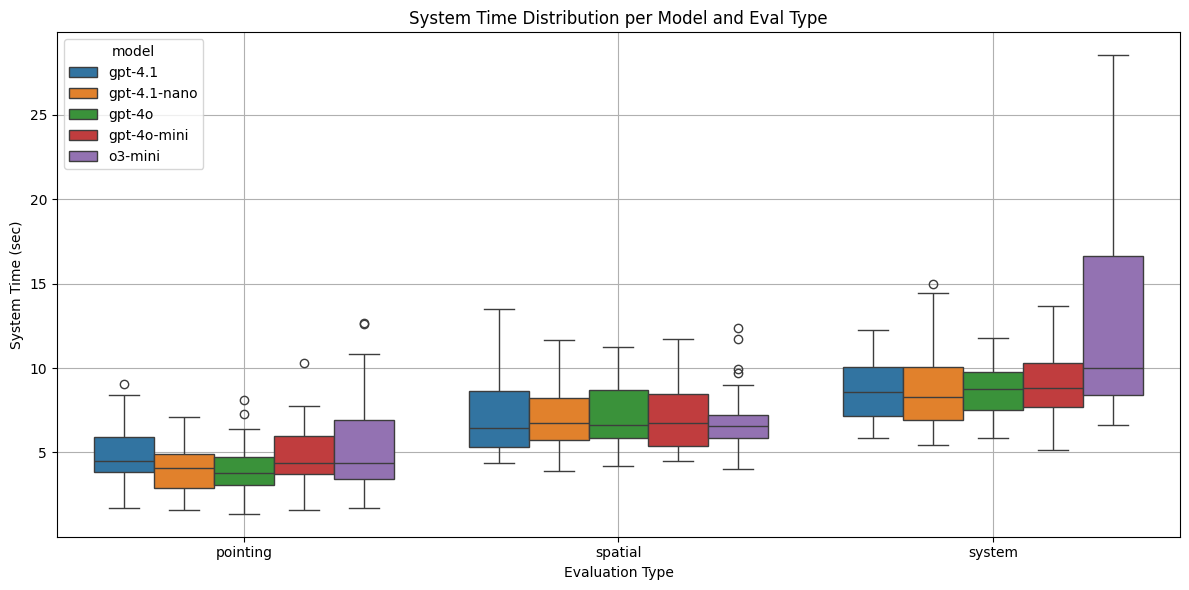

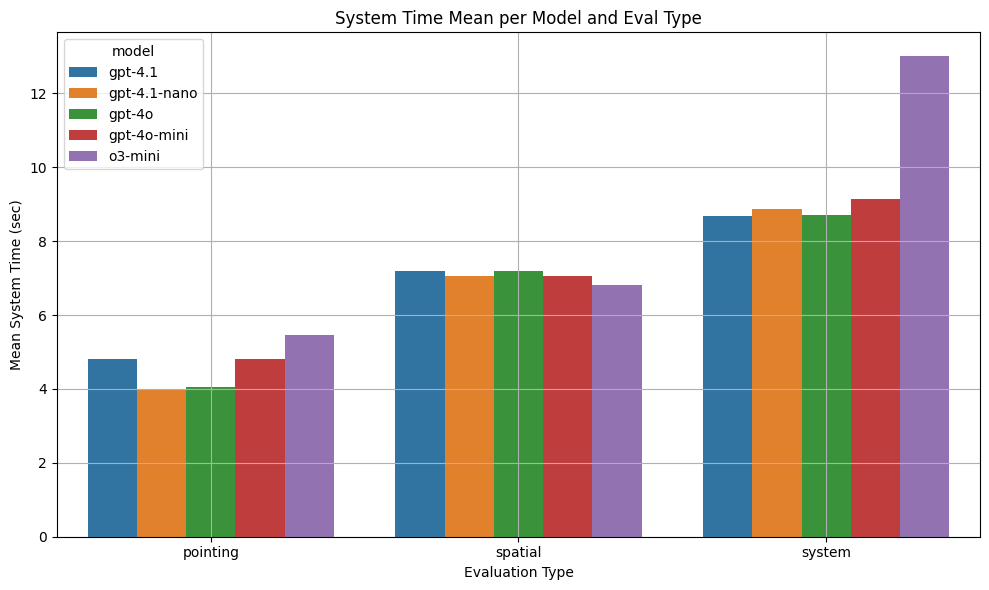

In [28]:
# 生データ取得（箱ひげ図用）
df_raw = collect_raw_system_times(evaluation_results)

# 外れ値除去
df_clean = remove_outliers_iqr_grouped(df_raw, "system_time_sec")

print(df_clean)
# 箱ひげ図！
plot_system_time_boxplot(df_clean)

# 要約統計も取得（平均バー用）
summary = df_clean.groupby(["model", "eval_type"])["system_time_sec"].agg(["min", "max", "mean"]).reset_index()
summary.rename(columns={"mean": "system_time_mean"}, inplace=True)

# バーグラフ！
plot_summary_barplot(summary)


# 性能評価

In [4]:
import pandas as pd

def compute_metrics_per_record(evaluation_results, task_id_to_info):
    rows = []

    for model, eval_types in evaluation_results.items():
        for eval_type, records in eval_types.items():
            for record in records:
                task_id = record.get("task_id")
                if task_id not in task_id_to_info:
                    continue

                # Ground truth device IDs
                ground_truth_ids = {d["deviceId"] for d in task_id_to_info[task_id]["devices"]}

                # Predicted device IDs
                if eval_type == "pointing":
                    predicted_ids = {d["id"] for d in record.get("metrics", {}).get("devices", [])}
                elif eval_type == "system":
                    predicted_ids = {d["id"] for d in record.get("filterAgent", {}).get("devices", [])}
                else:
                    predicted_ids = {d["id"] for d in record.get("agent_output", {}).get("devices", [])}

                # Accuracy（完全一致）
                is_exact_match = ground_truth_ids == predicted_ids

                # Precision / Recall / F1
                tp = len(ground_truth_ids & predicted_ids)
                fp = len(predicted_ids - ground_truth_ids)
                fn = len(ground_truth_ids - predicted_ids)

                precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
                recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
                f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0

                rows.append({
                    "model": model,
                    "eval_type": eval_type,
                    "task_id": task_id,
                    "accuracy": 1.0 if is_exact_match else 0.0,
                    "precision": precision,
                    "recall": recall,
                    "f1_score": f1,
                    "gt_count": len(ground_truth_ids),
                    "pred_count": len(predicted_ids)
                })

    return pd.DataFrame(rows)


In [5]:
df_melted = pointing_color_summary.melt(
    id_vars='model',
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1'],
    var_name='Metric',
    value_name='Score'
)

# グラフの描画設定
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# グループ化された棒グラフを作成
ax = sns.barplot(data=df_melted, x='model', y='Score', hue='Metric')

# グラフの各種設定
ax.set_title('Model Performance Comparison (Pointing with Color)', fontsize=16)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.1)  # y軸の範囲を0から1.1に設定して見やすくする
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# グラフを表示
plt.show()

NameError: name 'pointing_color_summary' is not defined

In [6]:
result = compute_metrics_per_record(evaluation_results, task_id_to_info)
result

,model,eval_type,task_id,accuracy,precision,recall,f1_score,gt_count,pred_count
0,1,unknown,c78550a2-290e-4b94-98db-961c2110c668,1.0,1.000000,1.000000,1.000000,4,4
1,1,unknown,c78550a2-290e-4b94-98db-961c2110c668,1.0,1.000000,1.000000,1.000000,4,4
2,2,unknown,8aeed698-e7ee-41ef-bfe7-56f37e2232ab,1.0,1.000000,1.000000,1.000000,3,3
3,2,unknown,8aeed698-e7ee-41ef-bfe7-56f37e2232ab,1.0,1.000000,1.000000,1.000000,3,3
4,3,unknown,2e919b0d-6d84-4641-a535-930a7ca6c8b7,0.0,1.000000,0.333333,0.500000,3,1
...,...,...,...,...,...,...,...,...,...
682,o3-mini,system,cd873fbb-fcc1-43bd-8f04-bb3b2d716af4,0.0,0.500000,0.833333,0.625000,6,10
683,o3-mini,system,ff4748e2-cd97-45bb-bf2c-e5c9c33f78ac,0.0,0.750000,1.000000,0.857143,3,4
684,o3-mini,system,4f145d76-f69f-4547-90a7-56281733ca5b,0.0,0.666667,1.000000,0.800000,2,3
685,o3-mini,system,137e922c-0877-46af-a797-5a32df2edf5d,0.0,0.333333,1.000000,0.500000,3,9


### 平均を見る

In [7]:
print(df_result[["Precision", "Recall", "F1"]].mean())

total_TP = df_result["TP_device"].sum()
total_FP = df_result["FP"].sum()
total_FN = df_result["FN"].sum()

overall_accuracy = total_TP / (total_TP + total_FP + total_FN)

total_tp_color = df_result["TP_device_color"].sum()
total_tp = df_result["TP_device"].sum()
total_fp = df_result["FP"].sum()
total_fn = df_result["FN"].sum()

accuracy_with_color = total_tp_color / (total_tp + total_fp + total_fn)
print(f"Overall Accuracy (without color): {overall_accuracy}　　(with color): {accuracy_with_color:.4f}")


total_color_mismatch = df_result["ColorMismatchCount"].sum()
mean_color_match_rate = df_result["ColorMatchRate"].dropna().mean()


total_color_mismatch, mean_color_match_rate

print(f"Color Math Rate: {mean_color_match_rate}, ColorMismatchCount: {total_color_mismatch}")



NameError: name 'df_result' is not defined

In [8]:
# model × eval_type で集計
summary_df = df_result.groupby(["model", "eval_type"]).agg({
    "TP_device": "sum",
    "TP_device_color": "sum",
    "FP": "sum",
    "FN": "sum",
    "Precision": "mean",
    "Recall": "mean",
    "F1": "mean",
    "ColorMatchRate": "mean",
    "system_time_elapsed": ["min", "max", "mean"]
}).reset_index()

# 列名をフラットに整形
summary_df.columns = [
    "Model", "EvalType",
    "TP_device", "TP_device_color", "FP", "FN",
    "Precision", "Recall", "F1", "ColorMatchRate",
    "MinTime", "MaxTime", "AvgTime"
]

# Accuracy（デバイスIDのみ）を計算
summary_df["Accuracy"] = summary_df["TP_device"] / (
    summary_df["TP_device"] + summary_df["FP"] + summary_df["FN"]
)

# Accuracy（デバイスID + 色）を計算
summary_df["Accuracy_Color"] = summary_df["TP_device_color"] / (
    summary_df["TP_device"] + summary_df["FP"] + summary_df["FN"]
)

# 列を整理して最終出力用のDataFrameに整形
summary_df = summary_df[
    ["Model", "EvalType", "Accuracy", "Accuracy_Color", "Precision", "Recall", "F1",
     "ColorMatchRate", "MinTime", "MaxTime", "AvgTime"]
]

summary_df

NameError: name 'df_result' is not defined

In [9]:
total_color_mismatch = summary_df["ColorMismatchCount"].sum()
mean_color_match_rate = summary_df["ColorMatchRate"].dropna().mean()


total_color_mismatch, mean_color_match_rate

NameError: name 'summary_df' is not defined

In [10]:
summary_df = df_result.groupby(["model", "eval_type"])[
    ["Precision", "Recall", "F1", "TP_device", "TP_device_color", "ColorMatchRate", "ColorMismatchCount", "Min]
].mean().reset_index()

summary_df.head()

SyntaxError: unterminated string literal (detected at line 2) (731210055.py, line 2)

In [11]:
def convert_ids_to_names(df, task_id_to_info, all_device_lists):
    # デバイスID → 名前マップ
    device_id_to_name = {d["id"]: d["name"] for d in all_device_lists}

    # task_id → タスク名マップ
    task_id_to_name = {tid: info["name"] for tid, info in task_id_to_info.items()}

    df = df.copy()
    df["task_name"] = df["task_id"].map(task_id_to_name)

    def map_ids_to_names(id_list):
        return [device_id_to_name.get(i, i) for i in id_list]

    df["Correct Devices"] = df["Correct IDs"].apply(map_ids_to_names)
    df["Extra Devices"] = df["Extra IDs"].apply(map_ids_to_names)
    df["Missing Devices"] = df["Missing IDs"].apply(map_ids_to_names)

    # 不要な列を整理
    df = df.drop(columns=["Correct IDs", "Extra IDs", "Missing IDs", "task_id"])
    df = df.rename(columns={"task_name": "Task Name"})

    return df


In [12]:
first_task = evaluation_results["gpt-4o"]["system"][0]
task_id = first_task["task_id"]
agent_devices = first_task["agent_output"]["devices"]
true_devices = task_id_to_info[task_id]["devices"]

print(agent_devices)
print(true_devices)

[{'id': '9cbd6e9a-4f7b-41e8-b1dc-464d631dfd7f', 'state': True, 'intensity': 100, 'color': {'r': 255, 'g': 165, 'b': 0}}, {'id': '6e82a90c-d3bb-4e45-b221-ebe21c524b04', 'state': True, 'intensity': 100, 'color': {'r': 255, 'g': 165, 'b': 0}}]
[{'deviceName': 'Ceiling Light 11', 'colorName': 'Orange', 'deviceId': '3da605b5-b12f-4fe8-9108-f4a6648efb3b'}, {'deviceName': 'Ceiling Light 12', 'colorName': 'Orange', 'deviceId': '10c15b3a-4b64-4eb7-8135-61ea6e1f9182'}]


In [13]:
# RGB→ColorNameマップ（必要に応じて拡張）
RGB_TO_COLOR_NAME = {
    # 基本色
    (255, 0, 0): "Red",
    (0, 128, 0): "Green",
    (0, 0, 255): "Blue",
    
    # 混合色
    (255, 255, 0): "Yellow",
    (0, 255, 255): "Cyan",
    (128, 0, 128): "Purple",
    (255, 165, 0): "Orange",

    # その他
    (255, 255, 255): "White",
    (0, 0, 0): "Black"
}

def rgb_to_name(rgb):
    return RGB_TO_COLOR.get((rgb["r"], rgb["g"], rgb["b"]), "Unknown")

# RGB→ColorNameマップ（必要に応じて拡張可能）
RGB_TO_COLOR = {
    (255, 0, 0): "Red",
    (0, 0, 255): "Blue",
    (0, 255, 0): "Green",
    (255, 255, 0): "Yellow",
    (255, 255, 255): "White",
    (255, 165, 0): "Orange",
    (128, 0, 128): "Purple",
    (0, 255, 255): "Cyan"
}

def rgb_to_name(rgb):
    return RGB_TO_COLOR.get((rgb["r"], rgb["g"], rgb["b"]), "Unknown")

def evaluate_device_and_color(agent_devices, true_devices):
    # ---------- ground-truth 辞書 ----------
    true_id_to_color = {d["deviceId"]: d["colorName"] for d in true_devices}

    # ---------- ID レベル ----------
    predicted_ids = {d["id"] for d in agent_devices}
    true_ids      = set(true_id_to_color.keys())

    id_TP = predicted_ids & true_ids
    id_FP = predicted_ids - true_ids
    id_FN = true_ids     - predicted_ids

    # ---------- 色レベル ----------
    color_TP = set()   # ID も色も合っている
    color_FP = set()   # ID は存在するが色が違う
    # ※「完全に別 ID」も FP として数えるなら id_FP を合算すれば OK

    for d in agent_devices:
        did = d["id"]
        if did in id_TP:
            # ID が正しいものだけ色を判定
            pred_color  = rgb_to_name(d["color"])
            true_color  = true_id_to_color[did]
            if pred_color == true_color:
                color_TP.add(did)
            else:
                color_FP.add(did)   # ID 合致・色不一致 → 色付きでは FP 扱い

    color_FN = {did for did in true_ids if did not in color_TP}  # 本来当たるべきだが色まで合っていない

    # ---------- 指標計算 ----------
    def _prf(tp, fp, fn):
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall    = tp / (tp + fn) if (tp + fn) else 0.0
        f1        = 2*precision*recall/(precision+recall) if (precision+recall) else 0.0
        return precision, recall, f1

    # 色なし（ID だけ）
    prec_id, rec_id, f1_id = _prf(len(id_TP), len(id_FP), len(id_FN))

    # 色あり（ID+Color）
    prec_col, rec_col, f1_col = _prf(len(color_TP), len(color_FP)+len(id_FP), len(color_FN))

    # ---------- まとめ ----------
    return {
        "no_color_metric": {
            "TP": len(id_TP),
            "FP": len(id_FP),
            "FN": len(id_FN),
            "Precision": prec_id,
            "Recall":    rec_id,
            "F1":        f1_id
        },
        "color_metric": {
            "TP": len(color_TP),
            "FP": len(color_FP) + len(id_FP),  # 完全別ID も色付きでは FP 扱い
            "FN": len(color_FN),
            "Precision": prec_col,
            "Recall":    rec_col,
            "F1":        f1_col
        },
        "ColorMatchRate": len(color_TP) / len(id_TP) if id_TP else None,
        "CorrectIDs":  list(id_TP),
        "ExtraIDs":    list(id_FP),
        "MissingIDs":  list(id_FN),
        "ColorMismatchIDs": list(color_FP),
    }


import pandas as pd

def remove_outliers_and_aggregate_by_model(df_result):
    grouped_results = []

    for model, group in df_result.groupby("model"):
        times = group["system_time_elapsed"]

        # 四分位数とIQRを計算
        Q1 = times.quantile(0.25)
        Q3 = times.quantile(0.75)
        IQR = Q3 - Q1

        # 外れ値のしきい値
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # 外れ値除去
        filtered = group[(times >= lower_bound) & (times <= upper_bound)]

        # 指標を集計
        result = {
            "model": model,
            "system_time_min": filtered["system_time_elapsed"].min(),
            "system_time_max": filtered["system_time_elapsed"].max(),
            "system_time_mean": filtered["system_time_elapsed"].mean(),
            "system_time_std": filtered["system_time_elapsed"].std(),
            "removed_outliers": len(group) - len(filtered),
            "retained_count": len(filtered)
        }
        grouped_results.append(result)

    return pd.DataFrame(grouped_results)



In [14]:
df_melted = pointing_color_summary.melt(
    id_vars='model',
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1'],
    var_name='Metric',
    value_name='Score'
)

# グラフの描画設定
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# グループ化された棒グラフを作成
ax = sns.barplot(data=df_melted, x='model', y='Score', hue='Metric')

# グラフの各種設定
ax.set_title('Model Performance Comparison (Pointing with Color)', fontsize=16)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.1)  # y軸の範囲を0から1.1に設定して見やすくする
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# グラフを表示
plt.show()

NameError: name 'pointing_color_summary' is not defined

# 結果を計算する　（これが今メインコード）

In [15]:
import pandas as pd
results_summary = []


        
for model, model_result in evaluation_results.items():
    for eval_type, records in model_result.items():
        for record in records:
            task_id = record["task_id"]
            agent_devices = record["agent_output"]["devices"]
            true_devices = task_id_to_info[task_id]["devices"]
            result["system_time_elapsed"] = record["system_total_time_sec"]
            result = evaluate_device_and_color(agent_devices, true_devices)
            result["task_id"] = task_id
            result["model"] = model
            result["eval_type"] = eval_type
            results_summary.append(result)

df_result = pd.DataFrame(results_summary)
df_result.head()

,no_color_metric,color_metric,ColorMatchRate,CorrectIDs,ExtraIDs,MissingIDs,ColorMismatchIDs,task_id,model,eval_type,system_time_elapsed
0,"{'TP': 4, 'FP': 0, 'FN': 0, 'Precision': 1.0, ...","{'TP': 4, 'FP': 0, 'FN': 0, 'Precision': 1.0, ...",1.000000,"[2125de35-62c2-40db-8bee-f0580a92ee8b, 5812640...",[],[],[],c78550a2-290e-4b94-98db-961c2110c668,1,unknown,10.851065
1,"{'TP': 4, 'FP': 0, 'FN': 0, 'Precision': 1.0, ...","{'TP': 4, 'FP': 0, 'FN': 0, 'Precision': 1.0, ...",1.000000,"[2125de35-62c2-40db-8bee-f0580a92ee8b, 5812640...",[],[],[],c78550a2-290e-4b94-98db-961c2110c668,1,unknown,4.990211
2,"{'TP': 3, 'FP': 0, 'FN': 0, 'Precision': 1.0, ...","{'TP': 3, 'FP': 0, 'FN': 0, 'Precision': 1.0, ...",1.000000,"[7ad8857c-4547-4f42-bcc0-dc17bd8e6fee, 80e64f7...",[],[],[],8aeed698-e7ee-41ef-bfe7-56f37e2232ab,2,unknown,8.067839
3,"{'TP': 3, 'FP': 0, 'FN': 0, 'Precision': 1.0, ...","{'TP': 2, 'FP': 1, 'FN': 1, 'Precision': 0.666...",0.666667,"[7ad8857c-4547-4f42-bcc0-dc17bd8e6fee, 80e64f7...",[],[],[80e64f7b-0589-4de7-977a-9d189a66fd1d],8aeed698-e7ee-41ef-bfe7-56f37e2232ab,2,unknown,3.393032
4,"{'TP': 1, 'FP': 0, 'FN': 2, 'Precision': 1.0, ...","{'TP': 1, 'FP': 0, 'FN': 2, 'Precision': 1.0, ...",1.000000,[badaeb49-9e87-4d7b-882e-be2e80f85c84],[],"[9cbd6e9a-4f7b-41e8-b1dc-464d631dfd7f, 6e82a90...",[],2e919b0d-6d84-4641-a535-930a7ca6c8b7,3,unknown,7.350140


In [16]:
import pandas as pd

# ───────────────────────────────────────────────
#  Series(dict) → TP/FP/FN Precision / Recall / F1 / Accuracy
# ───────────────────────────────────────────────
def _aggregate_metric_column(series_of_dicts: pd.Series) -> dict:
    df = series_of_dicts.apply(pd.Series)

    tp = df["TP"].sum()
    fp = df["FP"].sum()
    fn = df["FN"].sum()

    precision = tp / (tp + fp) if tp + fp else 0.0
    recall    = tp / (tp + fn) if tp + fn else 0.0
    f1        = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    accuracy  = tp / (tp + fp + fn) if tp + fp + fn else 0.0

    return {
        "TP"       : int(tp),
        "FP"       : int(fp),
        "FN"       : int(fn),
        "Precision": precision,
        "Recall"   : recall,
        "F1"       : f1,
        "Accuracy" : accuracy
    }

# ───────────────────────────────────────────────
#  モデル×評価タイプでまとめる  (ネスト辞書を持つ行を生成)
# ───────────────────────────────────────────────
def summarize_by_model_and_evaltype(df_result: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for (model, etype), grp in df_result.groupby(["model", "eval_type"]):
        # ---- 色なし / 色あり ----
        nc = _aggregate_metric_column(grp["no_color_metric"])
        wc = _aggregate_metric_column(grp["color_metric"])

        # ---- 時間統計 ----
        min_t = grp["system_time_elapsed"].min()
        max_t = grp["system_time_elapsed"].max()
        avg_t = grp["system_time_elapsed"].mean()
        cmr = grp["ColorMatchRate"].mean()

        rows.append({
            "model"         : model,
            "eval_type"     : etype,
            "no_color_metric": nc,
            "color_metric"   : wc,
            "color_match_rate": cmr,
            "min_time"       : float(min_t),
            "max_time"       : float(max_t),
            "avg_time"       : float(avg_t)
        })

    # 列順は必要に応じて調整
    return pd.DataFrame(rows, columns=[
        "model", "eval_type",
        "no_color_metric", "color_metric","color_match_rate",
        "min_time", "max_time", "avg_time"
    ])

# ----------------------------- 使い方 -----------------------------
summary_all  = pd.DataFrame(summarize_by_model_and_evaltype(df_result))
summary_all.head()

,model,eval_type,no_color_metric,color_metric,color_match_rate,min_time,max_time,avg_time
0,1,unknown,"{'TP': 8, 'FP': 0, 'FN': 0, 'Precision': 1.0, ...","{'TP': 8, 'FP': 0, 'FN': 0, 'Precision': 1.0, ...",1.000000,4.990211,10.851065,7.920638
1,2,unknown,"{'TP': 6, 'FP': 0, 'FN': 0, 'Precision': 1.0, ...","{'TP': 5, 'FP': 1, 'FN': 1, 'Precision': 0.833...",0.833333,3.393032,8.067839,5.730436
2,3,unknown,"{'TP': 1, 'FP': 0, 'FN': 2, 'Precision': 1.0, ...","{'TP': 1, 'FP': 0, 'FN': 2, 'Precision': 1.0, ...",1.000000,7.350140,7.350140,7.350140
3,4,unknown,"{'TP': 8, 'FP': 0, 'FN': 0, 'Precision': 1.0, ...","{'TP': 8, 'FP': 0, 'FN': 0, 'Precision': 1.0, ...",1.000000,4.299837,28.816406,16.558121
4,gpt-4.1,pointing,"{'TP': 141, 'FP': 0, 'FN': 0, 'Precision': 1.0...","{'TP': 130, 'FP': 11, 'FN': 11, 'Precision': 0...",0.931159,1.694347,14.631763,5.514875


In [17]:
import pandas as pd



def extract_color_mode_from_summary_all(summary_all, eval_type, with_color):
    # 1) pointing の行だけ抽出
    df_point = summary_all[summary_all["eval_type"] == eval_type].copy()
    
    # 2) color_metric 列（辞書）をそのまま DataFrame に展開
    color_df = df_point["color_metric" if with_color else "no_color_metric"].apply(pd.Series)
    
    # 3) 元の列と連結し、見たい列だけ並べ替え
    table = (
        # [FIX] "color_match_rate" をこのリストに追加します
        pd.concat([df_point[["model", "eval_type", "color_match_rate", "min_time", "max_time", "avg_time"]], color_df], axis=1)
          .loc[:, ["model", "Accuracy", "Precision", "Recall", "F1",
                   "TP", "FP", "FN", "color_match_rate",
                   "min_time", "max_time", "avg_time"]]
          .reset_index(drop=True)
    )

    return table


spatial_color_summary = extract_color_mode_from_summary_all(summary_all,"spatial", True)
system_color_summary = extract_color_mode_from_summary_all(summary_all,"system", True)
pointing_color_summary  = extract_color_mode_from_summary_all(summary_all,"pointing", True)


spatial_no_summary = extract_color_mode_from_summary_all(summary_all,"spatial", False)
system_no_summary = extract_color_mode_from_summary_all(summary_all,"system", False)
pointing_no_summary  = extract_color_mode_from_summary_all(summary_all,"pointing", False)



print(system_no_summary)



          model  Accuracy  Precision    Recall        F1     TP    FP    FN  \
0       gpt-4.1  0.536232   0.623596  0.792857  0.698113  111.0  67.0  29.0   
1  gpt-4.1-nano  0.549763   0.627027  0.816901  0.709480  116.0  69.0  26.0   
2        gpt-4o  0.592593   0.691358  0.805755  0.744186  112.0  50.0  27.0   
3   gpt-4o-mini  0.490476   0.569061  0.780303  0.658147  103.0  78.0  29.0   
4       o3-mini  0.585366   0.712871  0.765957  0.738462   72.0  29.0  22.0   

   color_match_rate  min_time   max_time   avg_time  
0          0.760526  4.123021  37.057552  10.500577  
1          0.841667  4.035056  31.495432  10.045626  
2          0.859649  2.195833  26.282245   9.875446  
3          0.819444  2.390814  34.441335  11.715024  
4          0.780247  6.622124  57.376737  16.484086  


In [18]:
import pandas as pd

import pandas as pd

import pandas as pd

import pandas as pd

def dataframe_to_latex(
    df_color: pd.DataFrame,
    df_no_color: pd.DataFrame,
    caption_main: str,
    caption_a: str,
    caption_b: str,
    label_main: str,
    label_a: str,
    label_b: str,
    use_small_font: bool = False,
) -> str:
    """
    1 つの Table 環境に (a) と (b) の表を上下に積む。
    (a) は「色あり＋時間」，(b) は「色なし」。
    時間3列の左側に縦罫線を挿入し，性能列と区切る。

    Parameters
    ----------
    df_color : DataFrame
        色あり＋時間のメトリクス
    df_no_color : DataFrame
        色なしのメトリクス
    caption_main : str
        Table 全体のキャプション（例: "Performance Comparison: …"）
    caption_a : str
        (a) のサブキャプション（例: "With Color + Time"）
    caption_b : str
        (b) のサブキャプション（例: "No Color Only"）
    label_main, label_a, label_b : str
        それぞれ \label{tab:...} 用の名前
    use_small_font : bool, default False
        True なら各サブテーブルを \small で縮小

    Returns
    -------
    str
        LaTeX 文字列
    """

    # ─────────────────────────────────────────────
    #  スタイラ作成：最良を緑，最悪を赤
    # ─────────────────────────────────────────────
    def make_styler(df: pd.DataFrame) -> pd.DataFrame:
        sty = pd.DataFrame("", index=df.index, columns=df.columns)
        low_is_good = ["FP", "FN", "min_time", "max_time", "avg_time"]
        for col in df.select_dtypes(include="number").columns:
            if df[col].nunique() < 2:
                continue
            best, worst = (
                (df[col].idxmin(), df[col].idxmax())
                if col in low_is_good
                else (df[col].idxmax(), df[col].idxmin())
            )
            if best != worst:
                sty.at[best, col] = r"\cellcolor{green!25}"
                sty.at[worst, col] = r"\cellcolor{red!25}"
        return sty

    # ─────────────────────────────────────────────
    #  前処理
    # ─────────────────────────────────────────────
    df_c = df_color.set_index("model")
    df_nc = df_no_color.set_index("model")
    sty_c, sty_nc = make_styler(df_c), make_styler(df_nc)

    perf_cols = ["Accuracy", "color_match_rate", "Precision", "Recall", "F1", "TP", "FP", "FN"]
    time_cols = ["min_time", "max_time", "avg_time"]
    cols_a = perf_cols + time_cols        # (a) 用
    cols_b = ["Accuracy", "Precision", "Recall", "F1", "TP", "FP", "FN"]  # (b) 用

    fmt = {c: ".3f" for c in ["Accuracy", "color_match_rate", "Precision", "Recall", "F1"]}
    fmt.update({"TP": "d", "FP": "d", "FN": "d", "min_time": ".2f", "max_time": ".2f", "avg_time": ".2f"})

    # ─────────────────────────────────────────────
    #  サブテーブル生成
    # ─────────────────────────────────────────────
    def subtable(df, styler, cols, subcap, sublabel):
        # 列フォーマット：時間列の手前で区切り線
        if any(c.startswith("min_time") for c in cols):
            split_idx = cols.index("min_time")
            col_fmt = "l|" + "c" * split_idx + "|" + "c" * (len(cols) - split_idx)
        else:
            col_fmt = "l|" + "c" * len(cols)

        lines = [
            r"\begin{subtable}[t]{\textwidth}",
            r"\centering",
            rf"\caption{{{subcap}}}",
            rf"\label{{tab:{sublabel}}}",
        ]
        if use_small_font:
            lines.append(r"\small")

        # ヘッダ
        header_perf = " & ".join([rf"\textbf{{{c.replace('_', ' ').title()[:5]}}}" for c in cols])
        lines += [
            rf"\begin{{tabular}}{{{col_fmt}}}",
            r"\toprule",
            rf"\textbf{{Model}} & {header_perf} \\",
            r"\midrule",
        ]

        # 行
        for mdl in df.index:
            row = [mdl]
            for c in cols:
                v = df.loc[mdl, c]
                sty = styler.loc[mdl, c]
                f = fmt.get(c, ".3f")
                txt = f"{int(v):d}" if f == "d" else f"{v:{f}}" if pd.notna(v) else ""
                row.append(f"{sty}{txt}")
            lines.append(" & ".join(row) + r" \\")

        lines += [r"\bottomrule", r"\end{tabular}", r"\end{subtable}", ""]
        return lines

    # ─────────────────────────────────────────────
    #  メインテーブル組み立て
    # ─────────────────────────────────────────────
    out = [
        r"\begin{table*}[htbp]",
        r"\centering",
        rf"\caption{{{caption_main}}}",
        rf"\label{{tab:{label_main}}}",
    ]
    out += subtable(df_c, sty_c, cols_a, f"{caption_a}", label_a)
    out += [r"\vspace{3mm}"]
    out += subtable(df_nc, sty_nc, cols_b, f"{caption_b}", label_b)
    out += [r"\end{table*}"]

    return "\n".join(out)






# ------------------------------------------------------------
# ❶ まず、上で定義した関数名を確認してください。
#    もし私が渡した関数が dataframe_to_latex_stacked() という名前なら
#    ↓ の呼び出しも stacked に合わせます。
#    ここでは関数名を dataframe_to_latex_stacked と想定します。
# ------------------------------------------------------------

# ========= System =========
latex_system_code = dataframe_to_latex_stacked(
    df_color=system_color_summary,
    df_no_color=system_no_summary,
    caption_main="Performance Comparison: Filter Agent + Spatial Agent",
    caption_a="With Color + Time",
    caption_b="No Color Only",
    label_main="system_perf",
    label_a="system_color",
    label_b="system_nocolor",
    use_small_font=False,   # True にすると \small で縮小
)

# ========= Spatial =========
latex_spatial_code = dataframe_to_latex_stacked(
    df_color=spatial_color_summary,
    df_no_color=spatial_no_summary,
    caption_main="Performance Comparison: All Devices + Spatial Agent",
    caption_a="With Color + Time",
    caption_b="No Color Only",
    label_main="spatial_perf",
    label_a="spatial_color",
    label_b="spatial_nocolor",
    use_small_font=False,
)

# ========= Pointing =========
latex_pointing_code = dataframe_to_latex_stacked(
    df_color=pointing_color_summary,
    df_no_color=pointing_no_summary,
    caption_main="Performance Comparison: Pointing + Spatial Agent",
    caption_a="With Color + Time",
    caption_b="No Color Only",
    label_main="pointing_perf",
    label_a="pointing_color",
    label_b="pointing_nocolor",
    use_small_font=False,
)

# ------------- 確認用 -------------
print(latex_system_code)
print()
print()
print(latex_spatial_code)
print()
print()
print(latex_pointing_code)


NameError: name 'dataframe_to_latex_stacked' is not defined

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------------------------------
# ① summary_all から時間データだけ抽出
#    必要な列: model, eval_type, avg_time
# -------------------------------------------------
time_df = summary_all[["model", "eval_type", "avg_time"]].copy()

# eval_type の並び順を明示的に決めたい場合
eval_order = ["pointing", "spatial", "system"]
time_df["eval_type"] = pd.Categorical(time_df["eval_type"], categories=eval_order, ordered=True)
time_df = time_df.sort_values(["eval_type", "model"])

# -------------------------------------------------
# ② 描画 (seaborn の barplot で “グループ化棒グラフ”)
# -------------------------------------------------
plt.figure(figsize=(10, 6))

sns.barplot(
    data   = time_df,
    x      = "eval_type",
    y      = "avg_time",
    hue    = "model",
    palette = "tab10"
)

plt.title("System Time Mean per Model and Eval Type", fontsize=14)
plt.xlabel("Evaluation Type")
plt.ylabel("Mean System Time (sec)")
plt.legend(title="model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()



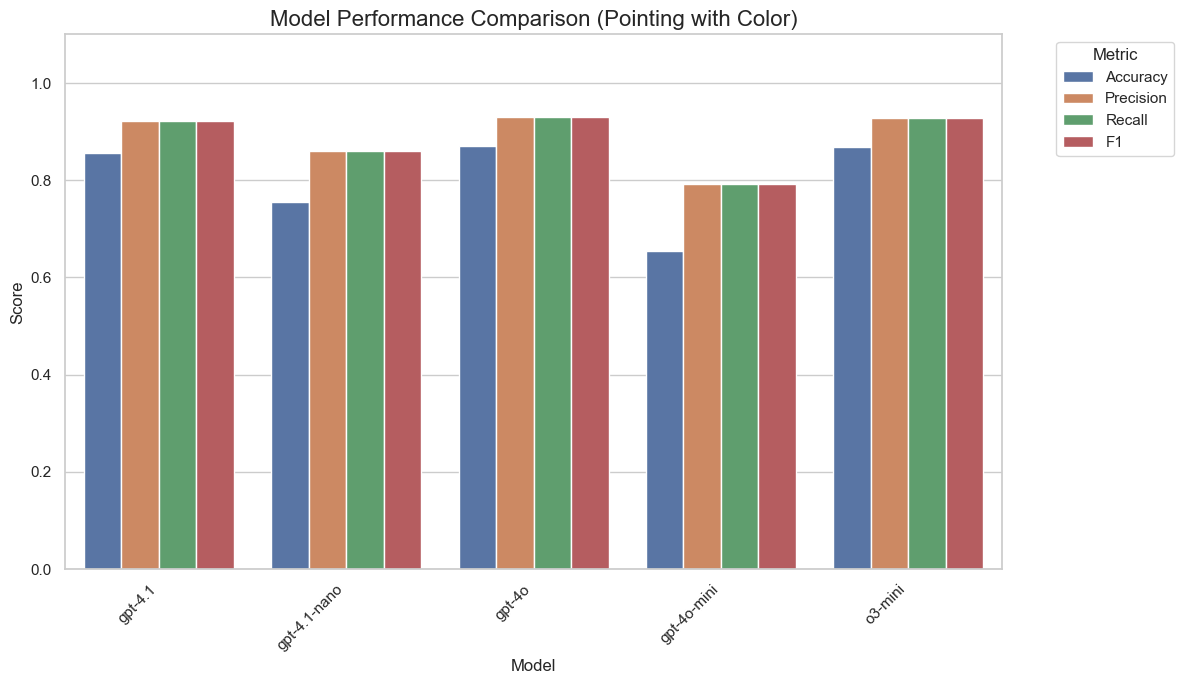

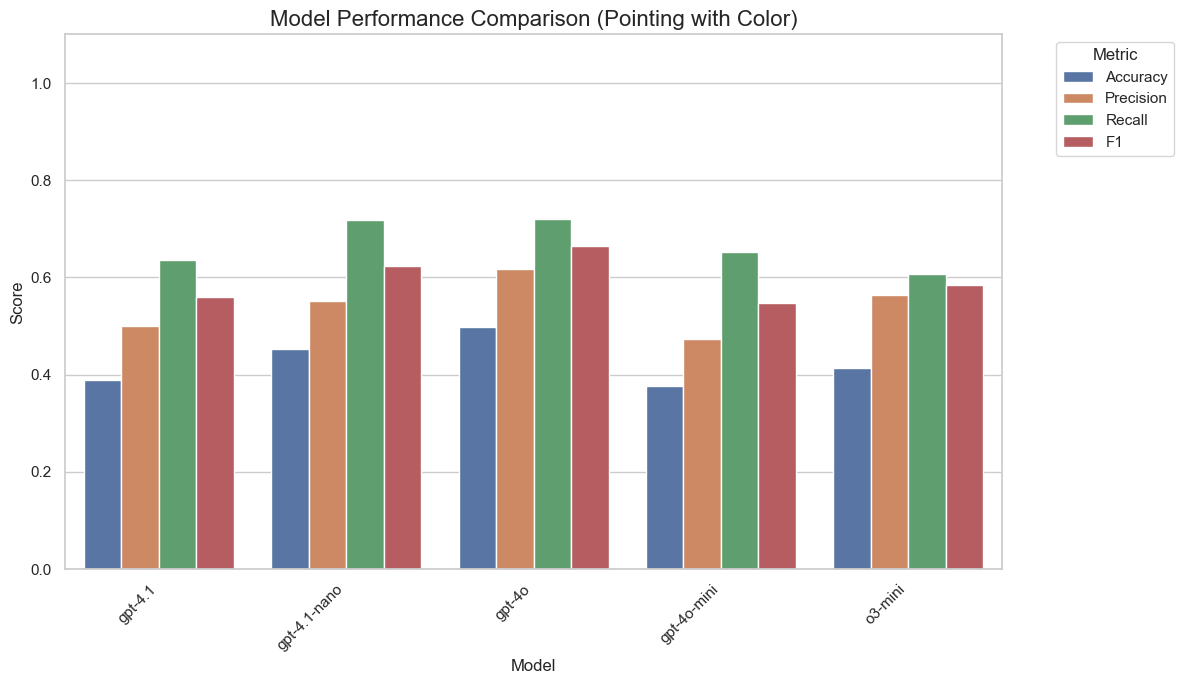

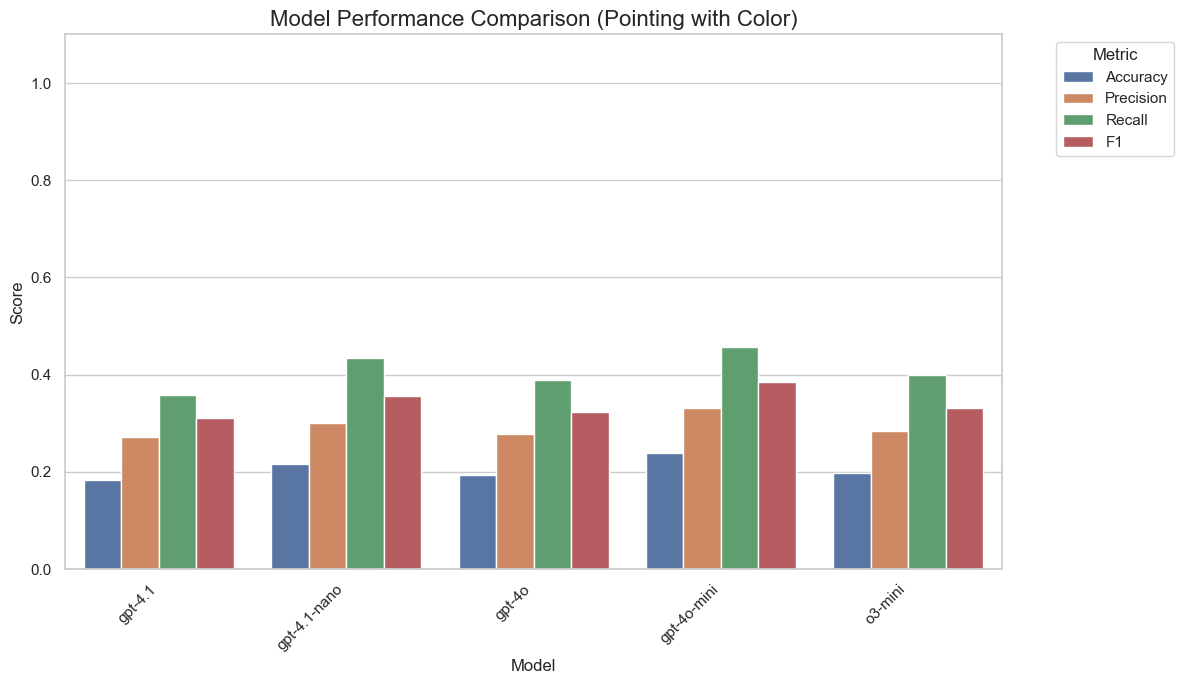

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



#================== Pointing =============================
# データを可視化に適した形式（ロングフォーマット）に変換
df_melted = pointing_color_summary.melt(
    id_vars='model',
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1'],
    var_name='Metric',
    value_name='Score'
)

# グラフの描画設定
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# グループ化された棒グラフを作成
ax = sns.barplot(data=df_melted, x='model', y='Score', hue='Metric')

# グラフの各種設定
ax.set_title('Model Performance Comparison (Pointing with Color)', fontsize=16)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.1)  # y軸の範囲を0から1.1に設定して見やすくする
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# グラフを表示
plt.show()





#======================= System ========================================

# データを可視化に適した形式（ロングフォーマット）に変換
df_melted = system_color_summary.melt(
    id_vars='model',
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1'],
    var_name='Metric',
    value_name='Score'
)

# グラフの描画設定
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# グループ化された棒グラフを作成
ax = sns.barplot(data=df_melted, x='model', y='Score', hue='Metric')

# グラフの各種設定
ax.set_title('Model Performance Comparison (Pointing with Color)', fontsize=16)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.1)  # y軸の範囲を0から1.1に設定して見やすくする
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# グラフを表示
plt.show()

# ====================================Spatial============================================

# データを可視化に適した形式（ロングフォーマット）に変換
df_melted = spatial_color_summary.melt(
    id_vars='model',
    value_vars=['Accuracy', 'Precision', 'Recall', 'F1'],
    var_name='Metric',
    value_name='Score'
)

# グラフの描画設定
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# グループ化された棒グラフを作成
ax = sns.barplot(data=df_melted, x='model', y='Score', hue='Metric')

# グラフの各種設定
ax.set_title('Model Performance Comparison (Pointing with Color)', fontsize=16)
ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.1)  # y軸の範囲を0から1.1に設定して見やすくする
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()

# グラフを表示
plt.show()

#　ここから古いの

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

df_plot = df_result.copy()
df_plot["Accuracy"] = df_plot["TP_device"] / (df_plot["TP_device"] + df_plot["FP"] + df_plot["FN"])
df_plot["Accuracy_with_color"] = df_plot["TP_device_color"] / (df_plot["TP_device"] + df_plot["FP"] + df_plot["FN"])

# モデル×評価タイプごとの平均
agg = df_plot.groupby(["model", "eval_type"])[["Accuracy", "Accuracy_with_color"]].mean().reset_index()

# 棒グラフ化
plt.figure(figsize=(12, 6))
sns.barplot(data=agg, x="eval_type", y="Accuracy", hue="model")
plt.title("Accuracy (without color) per model/eval_type")
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(data=agg, x="eval_type", y="Accuracy_with_color", hue="model")
plt.title("Accuracy (with color) per model/eval_type")
plt.ylim(0, 1)
plt.show()


KeyError: 'TP_device'

In [155]:
pointing_data = evaluation_results["gpt-4o"]["pointing"]

# 各pointed_devicesの長さを集めて平均を取る
candidate_counts = [len(entry["pointed_devices"]) for entry in pointing_data]
average_candidates = sum(candidate_counts) / len(candidate_counts)

print(f"Average number of pointed candidate devices: {average_candidates:.2f}")

Average number of pointed candidate devices: 3.06


In [156]:
# 各タスクセットのデバイス数をリスト化
device_counts = [len(task_set["devices"]) for task_set in all_task_sets]

# 平均を計算
average_devices_per_task = sum(device_counts) / len(device_counts)

print(f"平均デバイス数: {average_devices_per_task:.2f}")


平均デバイス数: 3.02


In [163]:
system_data = evaluation_results["gpt-4o"]["system"]

# 各試行における FilterAgent のデバイス数を抽出
filter_candidate_counts = [
    len(entry["filterAgent"]["devices"])
    for entry in system_data
    if "filterAgent" in entry and "devices" in entry["filterAgent"]
]

# 平均を計算
average_filter_candidates = sum(filter_candidate_counts) / len(filter_candidate_counts)

print(f"平均FilterAgent候補デバイス数 (system): {average_filter_candidates:.2f}")


平均FilterAgent候補デバイス数 (system): 7.18


In [158]:
system_data = evaluation_results["gpt-4o"]["system"]

# 各試行で選ばれたデバイスの数
selected_counts = [len(entry["selected_devices"]) for entry in system_data]

# 平均を計算
average_selected = sum(selected_counts) / len(selected_counts)

print(f"平均選択デバイス数 (system): {average_selected:.2f}")


平均選択デバイス数 (system): 3.62


In [159]:
system_data = evaluation_results["gpt-4o"]["spatial"]

# 各試行で選ばれたデバイスの数
selected_counts = [len(entry["selected_devices"]) for entry in system_data]

# 平均を計算
average_selected = sum(selected_counts) / len(selected_counts)

print(f"平均選択デバイス数 (system): {average_selected:.2f}")

平均選択デバイス数 (system): 4.30
